In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
lim=cv2.imread('/kaggle/input/kitti-stereo-evaluation-2015/training/image_2/000000_10.png',cv2.IMREAD_GRAYSCALE)
rim=cv2.imread('/kaggle/input/kitti-stereo-evaluation-2015/training/image_3/000000_10.png',cv2.IMREAD_GRAYSCALE)

In [3]:
assert lim is not None and rim is not None

In [4]:
ws=5

In [5]:
stero=cv2.StereoSGBM_create(minDisparity=0,
                           numDisparities=128,
                           blockSize=ws,
                           P1=8*ws**2,
                           P2=32*ws**2,
                           disp12MaxDiff=1,
                           uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY)

In [6]:
ldis=stero.compute(lim,rim).astype(np.float32)

In [7]:
ldis=ldis/16.0

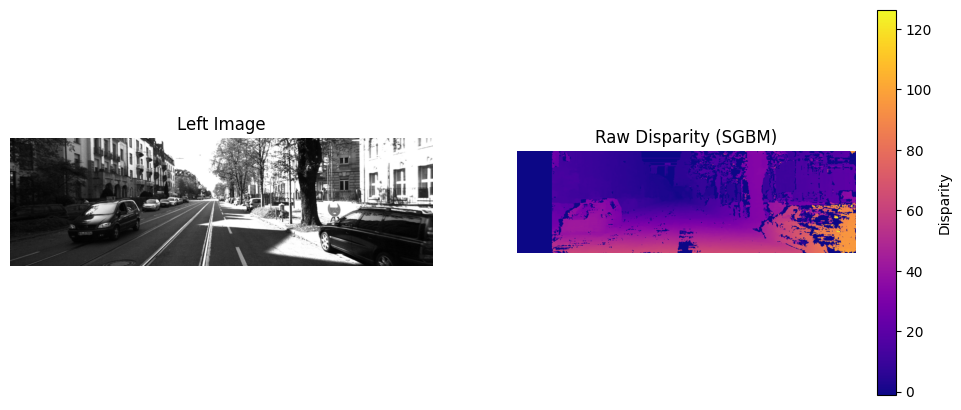

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Left Image")
plt.imshow(lim, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Raw Disparity (SGBM)")
plt.imshow(ldis, cmap='plasma')
plt.colorbar(label="Disparity")
plt.axis('off')
plt.show()

In [9]:
!pip uninstall opencv-python -y
!pip install opencv-contrib-python

Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88


In [10]:
wls=cv2.ximgproc.createDisparityWLSFilter(stero)

In [11]:
wls.setLambda(8000)
wls.setSigmaColor(1.5)

In [12]:
rm=cv2.ximgproc.createRightMatcher(stero)

In [13]:
rdis=rm.compute(rim,lim).astype(np.float32)/16.0

In [14]:
disp_wls = wls.filter(
    ldis,
    lim,
    None,
    rdis
)

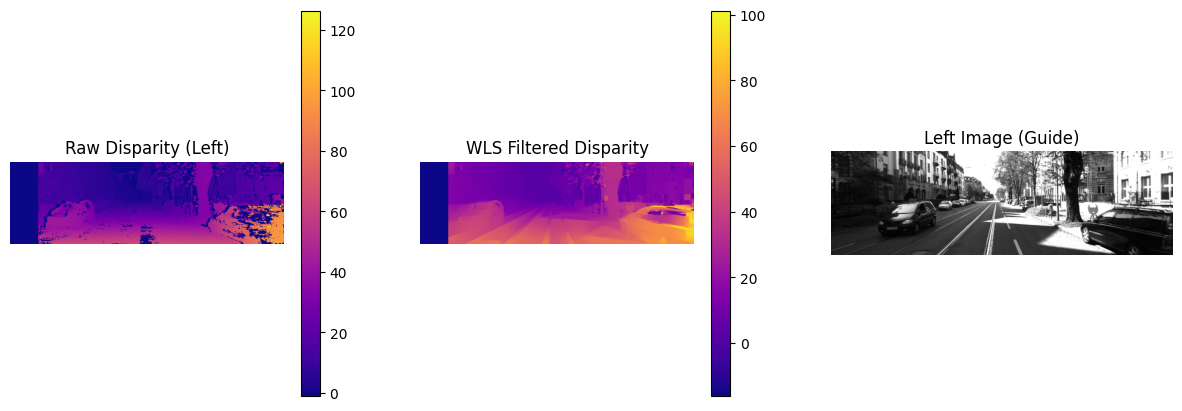

In [15]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Raw Disparity (Left)")
plt.imshow(ldis, cmap='plasma')
plt.colorbar()
plt.axis('off')

plt.subplot(1,3,2)
plt.title("WLS Filtered Disparity")
plt.imshow(disp_wls, cmap='plasma')
plt.colorbar()
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Left Image (Guide)")
plt.imshow(lim, cmap='gray')
plt.axis('off')

plt.show()


In [16]:
focal_length = 721.5377
baseline = 0.54
disp = disp_wls.copy()
disp[disp <= 0.0] = np.nan
depth = (focal_length * baseline) / disp


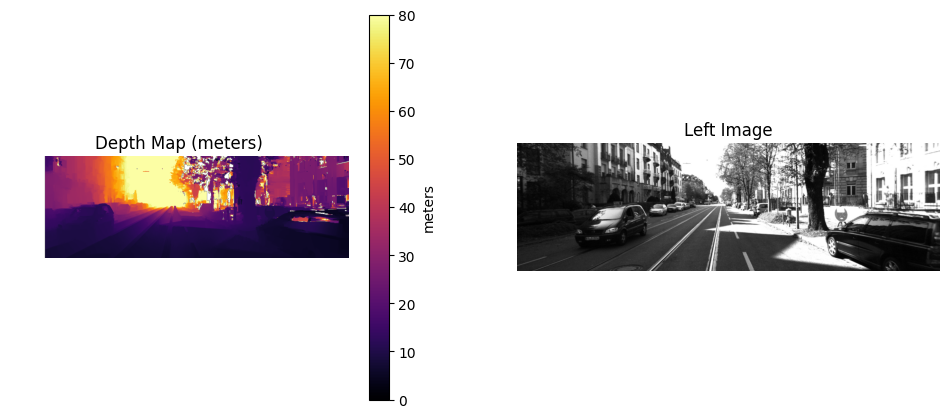

In [17]:
vis = np.clip(depth, 0, 80)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Depth Map (meters)")
plt.imshow(vis, cmap='inferno')
plt.colorbar(label="meters")
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Left Image")
plt.imshow(lim, cmap='gray')
plt.axis('off')

plt.show()


In [18]:
cx = 609.5593
cy = 172.8540

In [19]:
poi=[]
col=[]

In [20]:
h,w=depth.shape

In [21]:
h,w

(375, 1242)

In [22]:
for v in range(h):
    for u in range(w):
        Z=depth[v,u]
        if np.isnan(Z) or Z<=0 or Z>80:
            continue
        X=(u-cx)*Z/focal_length
        Y=(v-cy)*Z/focal_length
        poi.append([X,Y,Z])
        col.append(lim[v,u]/255.0)

In [23]:
poi=np.array(poi)
col=np.array(col)

In [24]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 105.2 MB/s eta 0:00:0000:0100:01


In [25]:
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [26]:
pcd=o3d.geometry.PointCloud()

In [27]:
pcd.points=o3d.utility.Vector3dVector(poi)

In [28]:
rgb=np.stack([col,col,col],axis=1)
pcd.colors=o3d.utility.Vector3dVector(rgb)

In [31]:
o3d.io.write_point_cloud("kitti_stereo.ply", pcd)

True